Load the cleaned dataset

In [ ]:
#notice we used "parse_dates" so we don't need to convert the date columns again.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/clean_superstore.csv",
    parse_dates=["order_date", "ship_date"],encoding="latin1"
)

## Univariate Analysis

Sales Column (Numeric)

Business Question: What is the distribution of sales per order?

In [ ]:
#Summary statistics for the sales column
df["sales"].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: sales, dtype: float64

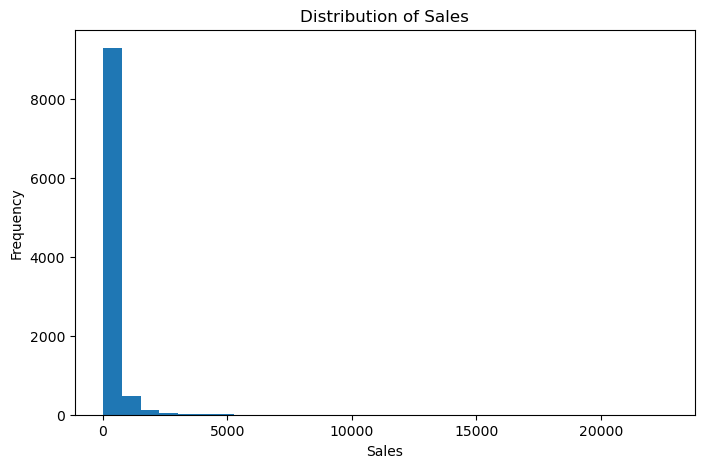

In [ ]:
#Visualizing the distribution of sales
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Interpretation: Most sales are relatively small, while a few very large orders create a long right tail. This indicates a positively skewed distribution.

Profit

Business Question: How are profits distributed?

In [4]:
#summary statistics for the profit column
df["profit"].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: profit, dtype: float64

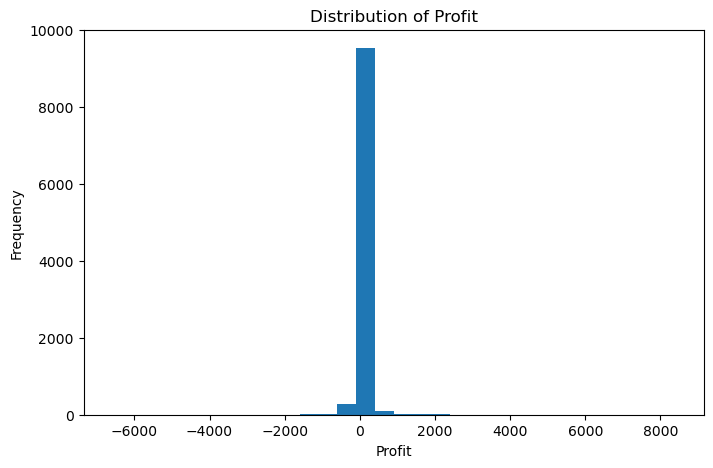

In [5]:
#visualizing the distribution of profit
plt.figure(figsize=(8,5))

plt.hist(df["profit"], bins=30)

plt.title("Distribution of Profit")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()

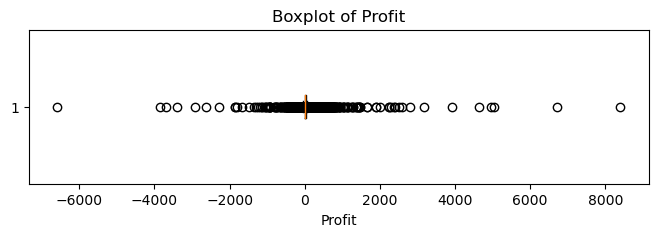

In [7]:
plt.figure(figsize=(8, 2))

plt.boxplot(df["profit"], vert=False)

plt.title("Boxplot of Profit")
plt.xlabel("Profit")

plt.show()

Interpretation: The distribution of Profit is heavily concentrated around 0, indicating that most orders generate relatively small profits or losses. There are negative profit values, which means some transactions resulted in losses. The distribution also contains a few extreme values on both sides, with some orders generating very high profits and others suffering large losses. Overall, the profit distribution is highly skewed and contains outliers.

Quantity

Business Question: How many items are typically purchased per order?

In [8]:
df["quantity"].describe()

count    9994.000000
mean        3.789574
std         2.225110
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: quantity, dtype: float64

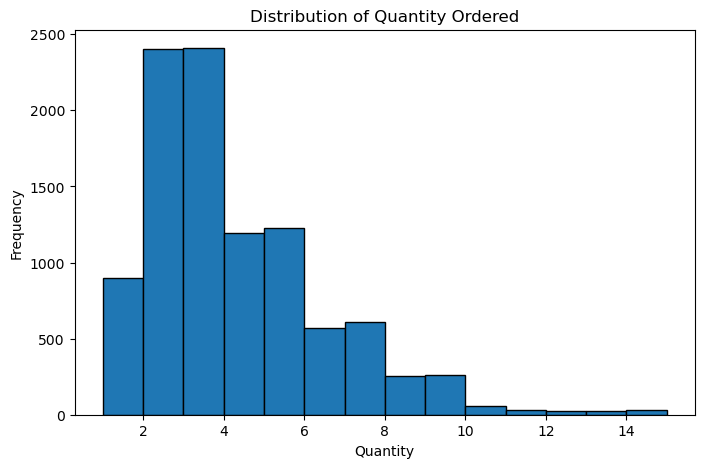

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["quantity"], bins=range(1, df["quantity"].max() + 2), edgecolor="black")

plt.title("Distribution of Quantity Ordered")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

Interpretation: The distribution of Quantity is right-skewed. Most orders contain a small number of items, with quantities between 2 and 5 being the most common. Orders with very large quantities are uncommon, indicating that customers typically purchase only a few items per transaction.

Discount

Business Question: How frequently are discounts applied?

In [10]:
df["discount"].describe()

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: discount, dtype: float64

In [11]:
df["discount"].value_counts().sort_index()

discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

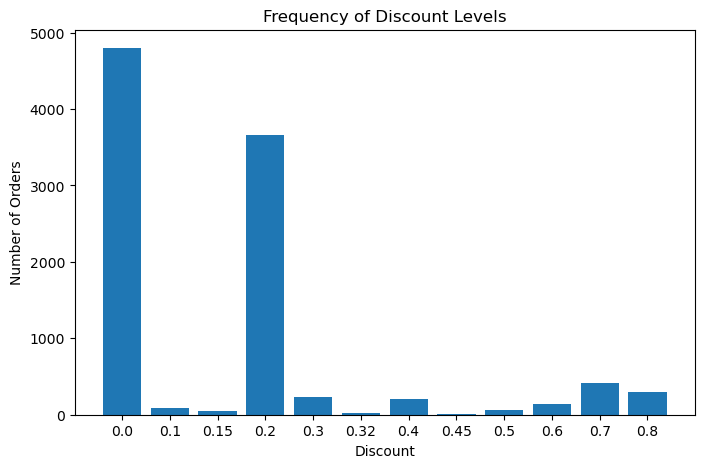

In [13]:
#barchart for visualization of discount levels
discount_counts = df["discount"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(discount_counts.index.astype(str), discount_counts.values)

plt.title("Frequency of Discount Levels")
plt.xlabel("Discount")
plt.ylabel("Number of Orders")

plt.show()

Interpretation: The majority of orders have no discount (0%), indicating that most products are sold at full price. Among discounted orders, 20% discounts are the most common, while higher discount levels occur much less frequently. This suggests that large discounts are applied only to a small proportion of orders.

Category

Business Question: Which product category receives the most orders?

In [14]:
df["category"].value_counts()

category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

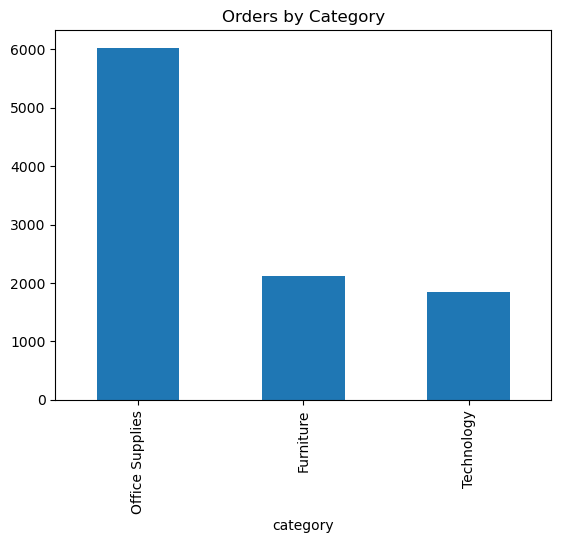

In [15]:
df["category"].value_counts().plot(kind="bar")

plt.title("Orders by Category")

plt.show()

Interpretation: We can see that office supplies has the most orders followed by furniture then technology.

Region

Business Question: Which region has the highest number of orders?

In [ ]:
df["region"].value_counts()

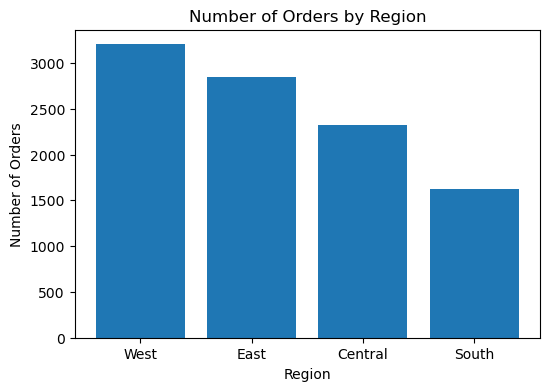

In [20]:
plt.figure(figsize=(6,4))

plt.bar(df["region"].value_counts().index, df["region"].value_counts().values)

plt.title("Number of Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.show()

Interpretation: We can see that most orders come from the west.

Segment

Business Question: How are orders distributed across customer segments?

In [19]:
df["segment"].value_counts()

segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

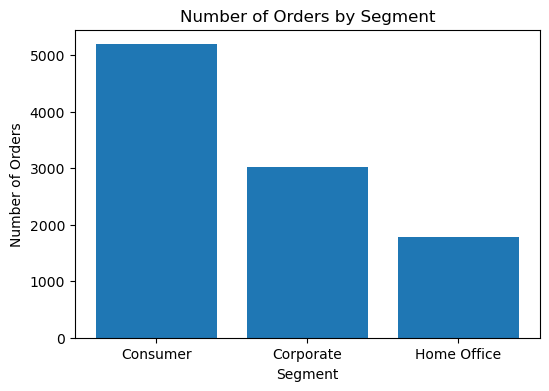

In [21]:
plt.figure(figsize=(6,4))

plt.bar(df["segment"].value_counts().index, df["segment"].value_counts().values)

plt.title("Number of Orders by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Orders")

plt.show()

Interpretation: The Consumer segment accounts for the largest number of orders, followed by Corporate and Home Office. This suggests that individual consumers make up the majority of the customer base.

Ship Mode

Business Question: Which shipping mode is used most frequently?

In [22]:
df["ship_mode"].value_counts()

ship_mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

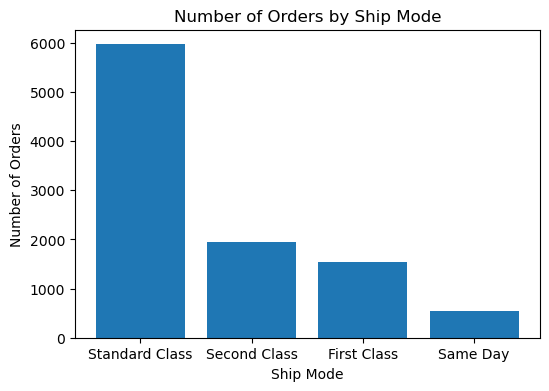

In [23]:
plt.figure(figsize=(6,4))

plt.bar(df["ship_mode"].value_counts().index, df["ship_mode"].value_counts().values)

plt.title("Number of Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.show()

Interpretation: Standard Class is the most commonly used shipping method, indicating that customers generally prefer the standard delivery option.

## Bivariate Analysis

Sales by Category

Business Question: Which product category generates the highest sales?

In [24]:
sales_by_category = df.groupby("category")["sales"].sum().sort_values(ascending=False)
sales_by_category

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

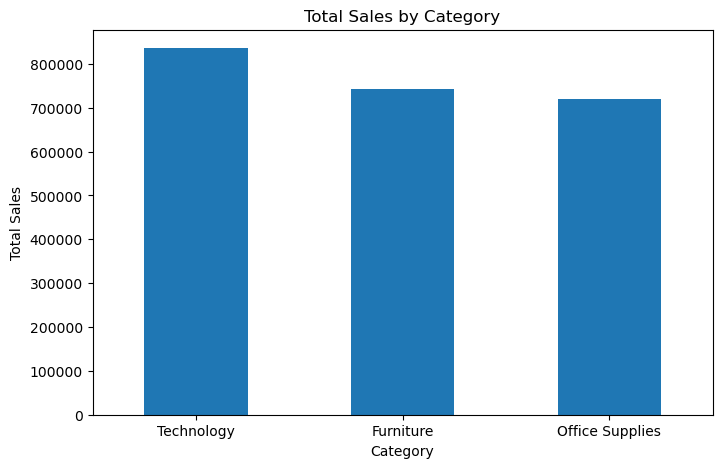

In [25]:
plt.figure(figsize=(8,5))

sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

    Interpretation: Technology region has the most sales generating the most revenue, while office suplies generates the least revenue despite having the most orders.

Profit by Category

Business Question: Which product category is the most profitable ?

In [26]:
profit_by_category = df.groupby("category")["profit"].sum().sort_values(ascending=False)

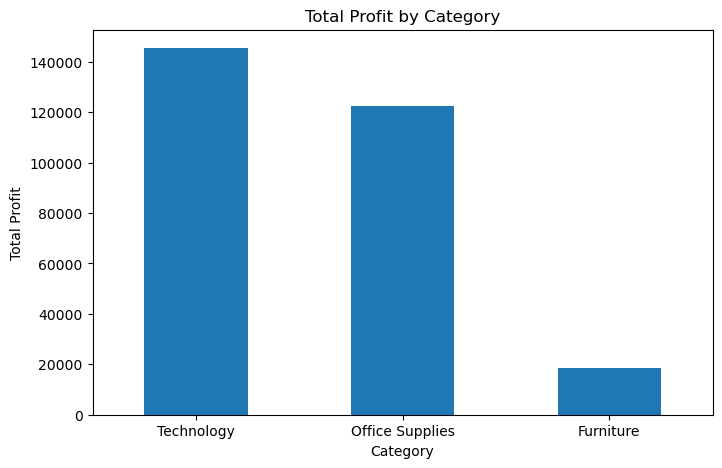

In [27]:
plt.figure(figsize=(8,5))

profit_by_category.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.show()

Interpretation: High sales don't always mean high profit. Highest profit comes from technology, followed by office supplies category then furniture.

Sales by Region

Business Question: Which region generates the highest sales?

In [29]:
sales_by_region = df.groupby("region")["sales"].sum().sort_values(ascending=False)
sales_by_region

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

Interpretation: West region generates highest sales.

Profit by Region

Business Question: Which region contributes the most profit?

In [30]:
profit_by_region = df.groupby("region")["profit"].sum().sort_values(ascending=False)

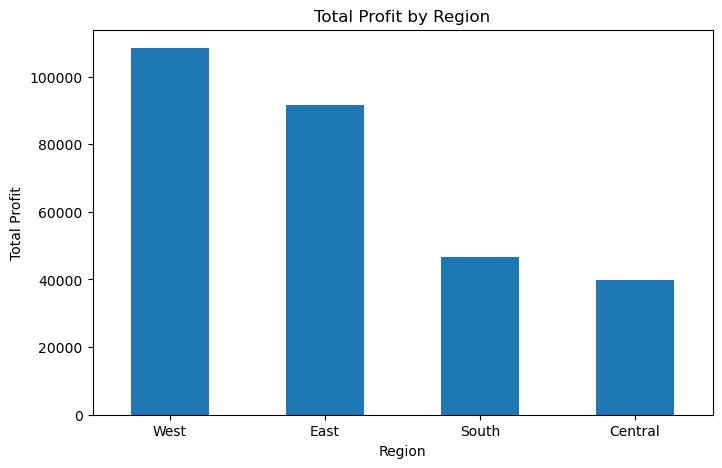

In [31]:
plt.figure(figsize=(8,5))

profit_by_region.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.show()

Interpretation: Similarly to sales, the west region generates more profit.

Sales by Segment

Business Question: Which customer segment generates the highest sales?

In [34]:
sales_by_segment = df.groupby("segment")["sales"].sum().sort_values(ascending=False)

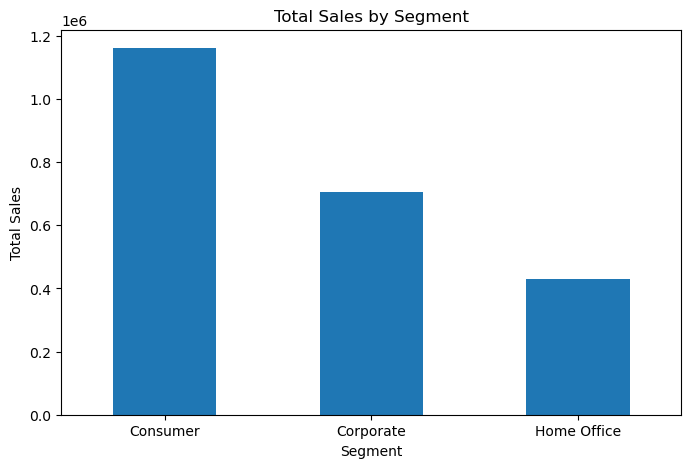

In [35]:
plt.figure(figsize=(8,5))

sales_by_segment.plot(kind="bar")

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

Interpretation: The Consumer segment accounts for the largest number of sales, followed by Corporate and Home Office.

Sales by Ship Mode

Business Question: Which shipping mode is associated with the highest sales?

In [38]:
sales_by_ship = df.groupby("ship_mode")["sales"].sum().sort_values(ascending=False)

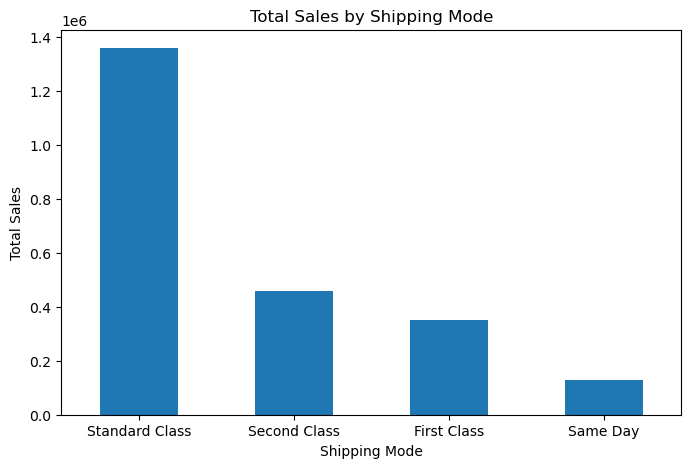

In [39]:
plt.figure(figsize=(8,5))

sales_by_ship.plot(kind="bar")

plt.title("Total Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

Interpretation:

Sales vs Profit

Business Question: Is there a relationship between sales and profit?

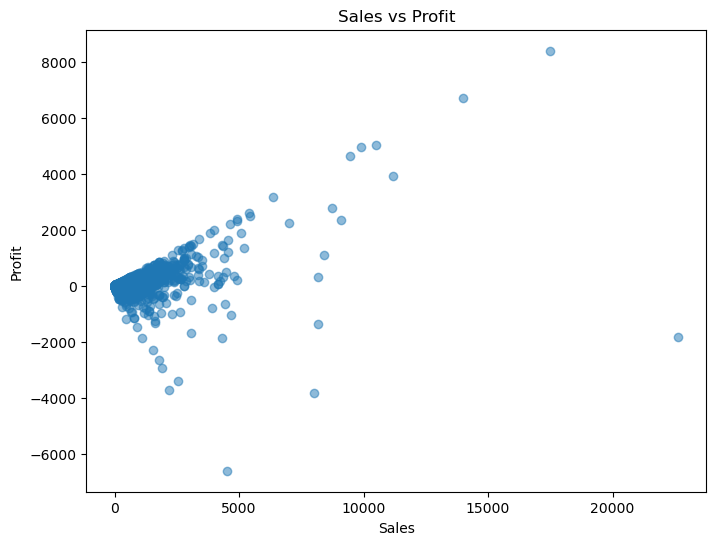

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(df["sales"], df["profit"], alpha=0.5)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

Interpretation: 
The scatter plot shows a positive relationship between Sales and Profit, meaning that orders with higher sales generally tend to generate higher profits. However, the relationship is not perfectly linear, as profits vary considerably for similar sales values. The plot also reveals several high-sales orders with negative profits, indicating that some expensive orders resulted in losses. These losses may be associated with heavy discounts, high shipping costs, or low profit margins. Overall, increasing sales does not always guarantee increased profitability.

Discount vs Profit 

Business Question: Does offering larger discounts reduce profit?

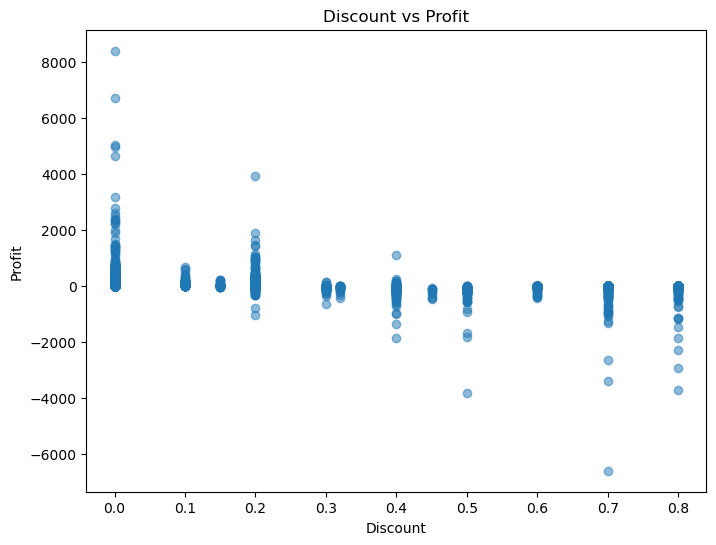

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(df["discount"], df["profit"], alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Interpretation: The scatter plot indicates a negative relationship between Discount and Profit. As discount levels increase, profits generally decrease. Many orders with little or no discount remain profitable, whereas heavily discounted orders are more likely to generate low or negative profits. Several high-discount orders result in losses, suggesting that excessive discounting may significantly reduce profitability. This highlights the importance of evaluating discount strategies to ensure they drive sales without sacrificing profit.

Quantity vs Sales

Business Question: Do orders with more items generally generate higher sales?

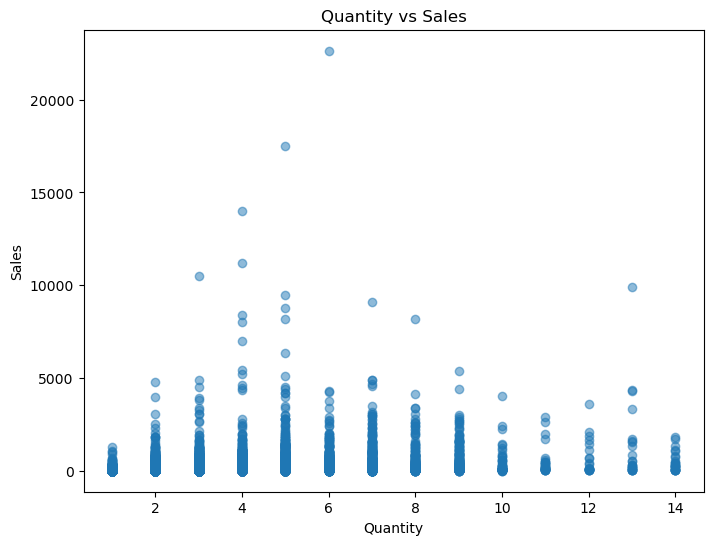

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(df["quantity"], df["sales"], alpha=0.5)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

Interpretation: The scatter plot shows a positive relationship between Quantity and Sales. In general, orders containing more items tend to have higher sales values. However, the relationship is not perfectly linear, as orders with the same quantity can have very different sales amounts. This suggests that the price of the products purchased also has a significant impact on total sales. There are also a few high-sales outliers, indicating expensive orders that may not necessarily contain many items.

## Time Based Analysis

Business Question 1

How have sales changed over time?

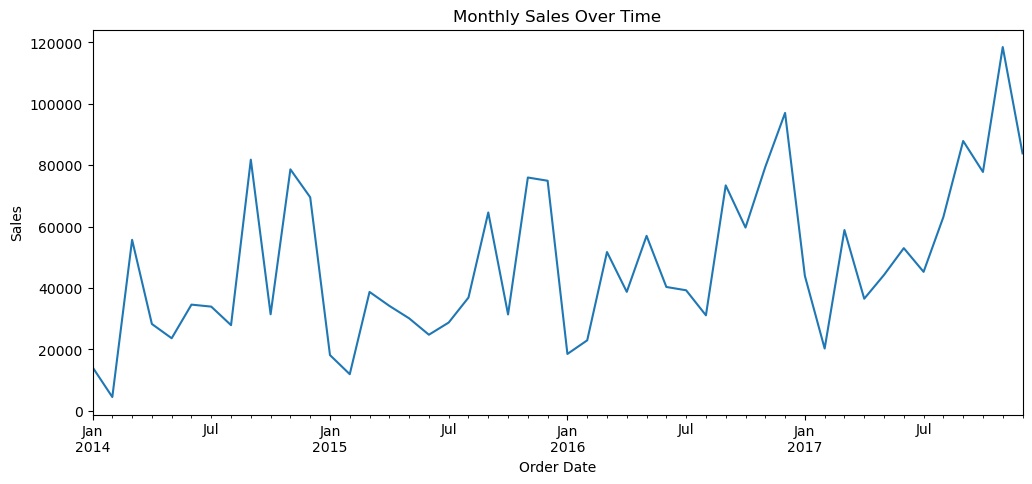

In [44]:
monthly_sales = (
    df.set_index("order_date")["sales"]
      .resample("M")
      .sum()
)

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()

Business Question 2

How has profit changed over time?

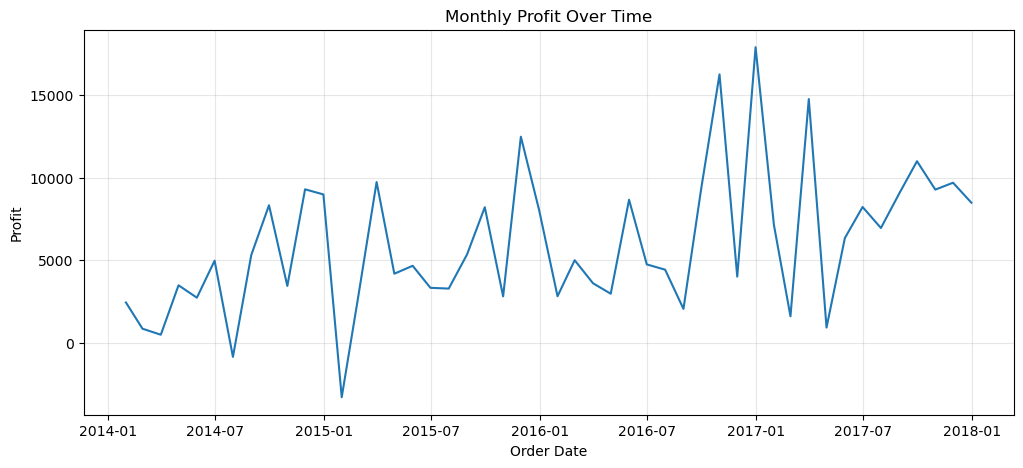

In [48]:
monthly_profit = (
    df.set_index("order_date")["profit"]
      .resample("M")
      .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(monthly_profit.index, monthly_profit.values)

plt.title("Monthly Profit Over Time")
plt.xlabel("Order Date")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

Business Question 3

Are there seasonal peaks in sales?

Interpretation: Sales fluctuate over time, with several noticeable peaks. These peaks suggest the possibility of seasonal demand, which will be investigated further after creating month-based features.

## Outlier Investigation

Business Question: Are there unusually large sales or losses that deserve attention?

In [45]:
#Largest sales
df.nlargest(10, "sales")

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,4278,US-2016-107440,2016-04-16,2016-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6425,6426,CA-2016-143714,2016-05-23,2016-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [46]:
#Largest Losses 
df.nlargest(10, "sales")

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,4278,US-2016-107440,2016-04-16,2016-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6425,6426,CA-2016-143714,2016-05-23,2016-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


## Correlation Analysis

Business Question: Which numeric variables are most strongly related?

In [43]:
df[["sales", "profit", "quantity", "discount"]].corr()

,sales,profit,quantity,discount
sales,1.000000,0.479064,0.200795,-0.028190
profit,0.479064,1.000000,0.066253,-0.219487
quantity,0.200795,0.066253,1.000000,0.008623
discount,-0.028190,-0.219487,0.008623,1.000000


Interpretation:

The correlation analysis shows that Sales and Profit have a moderate positive relationship, indicating that orders with higher sales generally generate higher profits. However, the relationship is not perfect, meaning some high-sales orders still produce low or negative profits.

Discount and Profit exhibit a negative relationship, suggesting that as discounts increase, profits tend to decrease. This supports the observation that excessive discounting can reduce profitability and even result in losses.

Quantity and Sales are positively correlated, meaning orders with more items generally have higher sales. However, the relationship is weaker than Sales and Profit because product prices vary across different items.

Overall, Sales and Profit show the strongest positive relationship, while Discount and Profit demonstrate the strongest negative relationship. These findings indicate that profitability depends not only on increasing sales but also on maintaining effective pricing and discount strategies.

## EDA Summary

Key Findings

-Sales are right-skewed, with many small orders and a few very large ones.

-Technology is the highest-performing category in terms of sales.

-The West region generates the highest sales.

-Consumer is the largest customer segment.

-Higher discounts are associated with lower profits.

-Some high-sales orders still result in negative profit.

-Large losses exist but appear to be valid business records.